In [24]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm

In [25]:
# ------------------------------------------------------------
# 1) DEFINITION OF FILE PATHS AND CO2 EMISSION FACTORS
# ------------------------------------------------------------

# List of CSV file paths for "Actual Generation per Production Type"
files = [
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_201901010000-202001010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202001010000-202101010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202101010000-202201010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202201010000-202301010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202301010000-202401010000.csv',
    'C:\\Users\\49176\\Task3\\Actual Generation per Production Type_202401010000-202501010000.csv',
]

# Dictionary of CO2 emission factors in g/kWh for each energy source

emission_factors = {
    "Biomass - Actual Aggregated [MW]": 0.0,
    "Fossil Brown coal/Lignite - Actual Aggregated [MW]": 0.0,
    "Fossil Gas - Actual Aggregated [MW]": 390.43,
    "Fossil Hard coal - Actual Aggregated [MW]": 1044.87,
    "Solar - Actual Aggregated [MW]": 0.0,
    "Wind Onshore - Actual Aggregated [MW]": 0.0,
    "Nuclear - Actual Aggregated [MW]": 0.0,
    "Hydro Run-of-river and poundage - Actual Aggregated [MW]": 0.0,
    "Hydro Water Reservoir - Actual Aggregated [MW]": 0.0
}



In [26]:
# ------------------------------------------------------------
# 2) FUNCTION TO LOAD AND COMBINE CSV FILES
# ------------------------------------------------------------
def load_and_combine(files):
    """
    Reads multiple CSV files and concatenates them into one DataFrame.
    - 'MTU' column is split to extract the start time (e.g. "01.01.2019 00:00").
    - The extracted time string is converted to a Pandas DateTime.
    - Finally, returns a single DataFrame with all rows from each file.
    """
    combined_data = []
    
    # Loop through each file in the list
    for file in files:
        # Read CSV
        df = pd.read_csv(file, low_memory=False)
        
        # Split the 'MTU' column on delimiter ' - ', 
        df['DateTime'] = pd.to_datetime(df['MTU'].str.split(' - ').str[0], format="%d.%m.%Y %H:%M")
        
        # Append the loaded DataFrame to a temporary list
        combined_data.append(df)
    
    # Concatenate all DataFrames in the list into one DataFrame 
    return pd.concat(combined_data, ignore_index=True)


In [27]:
# ------------------------------------------------------------
# 3) LOAD AND PREPARE THE DATA
# ------------------------------------------------------------
# Load all CSV files into one DataFrame using the function
actual_generation = load_and_combine(files)

# Keep only relevant columns for the analysis
actual_generation = actual_generation[[
    'DateTime',
    'Biomass - Actual Aggregated [MW]',
    'Fossil Brown coal/Lignite - Actual Aggregated [MW]',
    'Fossil Gas - Actual Aggregated [MW]',
    'Fossil Hard coal - Actual Aggregated [MW]',
    'Solar - Actual Aggregated [MW]',
    'Wind Onshore - Actual Aggregated [MW]',
    'Nuclear - Actual Aggregated [MW]',
    'Hydro Run-of-river and poundage - Actual Aggregated [MW]',
    'Hydro Water Reservoir - Actual Aggregated [MW]'
]]


In [28]:
# ------------------------------------------------------------
# 4) DATA CLEANING AND ADDITIONAL TIME COLUMNS
# ------------------------------------------------------------

# Convert all relevant columns (except DateTime) to numeric types
# If conversion fails, it becomes NaN, which is then filled with 0.
for col in actual_generation.columns[1:]:
    actual_generation[col] = pd.to_numeric( actual_generation[col],errors='coerce'  ).fillna(0)

# Extract the 'Year' from the DateTime
actual_generation['Year'] = actual_generation['DateTime'].dt.year

# Extract the 'Month' in the format  by converting to string
actual_generation['Month'] = actual_generation['DateTime'].dt.to_period('M').astype(str)

# not needed
actual_generation = actual_generation.drop(columns=['DateTime'])


In [29]:
# 5) GROUPING BY YEAR FOR AGGREGATED ANALYSIS
# ------------------------------------------------------------

# yearly_generation will hold the sum of all sources per year
yearly_generation = actual_generation.groupby('Year').sum()

# ------------------------------------------------------------
# 6) CALCULATE CO2 INTENSITY
# ------------------------------------------------------------
def calculate_co2_intensity(row):
    """
    Given a row of power values (MW) for each source,
    compute total_production and multiply each source by its emission factor,
    then compute 'co2_emissions / total_production'.
    """
    # Sum of all energy generation in that row
    total_production = row.sum()
    
    # Calculate total emissions from all sources in that row
    co2_emissions = sum(row[col] * factor for col, factor in emission_factors.items())
    
    
    # avoid dividing 0
    return co2_emissions / total_production if total_production > 0 else 0

# Add a column 'CO2_Intensity' to the DataFrame by applying the function row-wise
# Over only the columns we have emission factors for.
actual_generation['CO2_Intensity'] = actual_generation[list(emission_factors.keys())].apply(calculate_co2_intensity, axis=1)

In [30]:
# ------------------------------------------------------------
# 7) CREATE ADDITIONAL COLUMNS FOR RENEWABLES, COAL, AND GAS
# ------------------------------------------------------------

# Sum relevant sources to get the total Renewables in MW
actual_generation['Renewables'] = (
    actual_generation['Biomass - Actual Aggregated [MW]'] +
    actual_generation['Solar - Actual Aggregated [MW]'] +
    actual_generation['Wind Onshore - Actual Aggregated [MW]'] +
    actual_generation['Hydro Run-of-river and poundage - Actual Aggregated [MW]'] +
    actual_generation['Hydro Water Reservoir - Actual Aggregated [MW]']
)

# Combine brown coal and hard coal into 'Coal'
actual_generation['Coal'] = (actual_generation['Fossil Brown coal/Lignite - Actual Aggregated [MW]'] +actual_generation['Fossil Hard coal - Actual Aggregated [MW]'])

# Gas column only
actual_generation['Gas'] = actual_generation['Fossil Gas - Actual Aggregated [MW]']

In [8]:
# ------------------------------------------------------------
# 8) YEARLY SHARES (RENEWABLES, COAL, GAS) AS PERCENTAGES
# ------------------------------------------------------------
numeric_columns = actual_generation.select_dtypes(include=['number']).columns

# sum years
yearly_shares = actual_generation.groupby('Year')[['Renewables', 'Coal', 'Gas']].sum()

# Compute the total generation of all numeric columns, then sum across columns for each year   
yearly_totals = actual_generation.groupby('Year')[numeric_columns].sum().sum(axis=1)

# Divide each category by the total and multiply by 100 to get percentages
yearly_shares = yearly_shares.div(yearly_totals, axis=0) * 100

In [9]:
# ------------------------------------------------------------
# 9) MONTHLY SHARES FOR VISUALIZATION
# ------------------------------------------------------------
monthly_shares = actual_generation.groupby('Month')[['Renewables', 'Coal', 'Gas']].sum()
monthly_totals = actual_generation.groupby('Month')[numeric_columns].sum().sum(axis=1) #same procedure as top
monthly_generation_percentage = monthly_shares.div(monthly_totals, axis=0) * 100

# Ensure yearly_generation has numeric values (e.g. if something was object type)
yearly_generation = yearly_generation.apply(pd.to_numeric, errors='coerce').fillna(0)

# Compute yearly_generation_percentage: the ratio of each generation type to the total sum
yearly_generation_percentage = yearly_generation.div(yearly_generation.sum(axis=1), axis=0) * 100

# Drop the 'Month' column if it exists in yearly_generation_percentage
yearly_generation_percentage = yearly_generation_percentage.drop( columns=['Month'], errors='ignore')

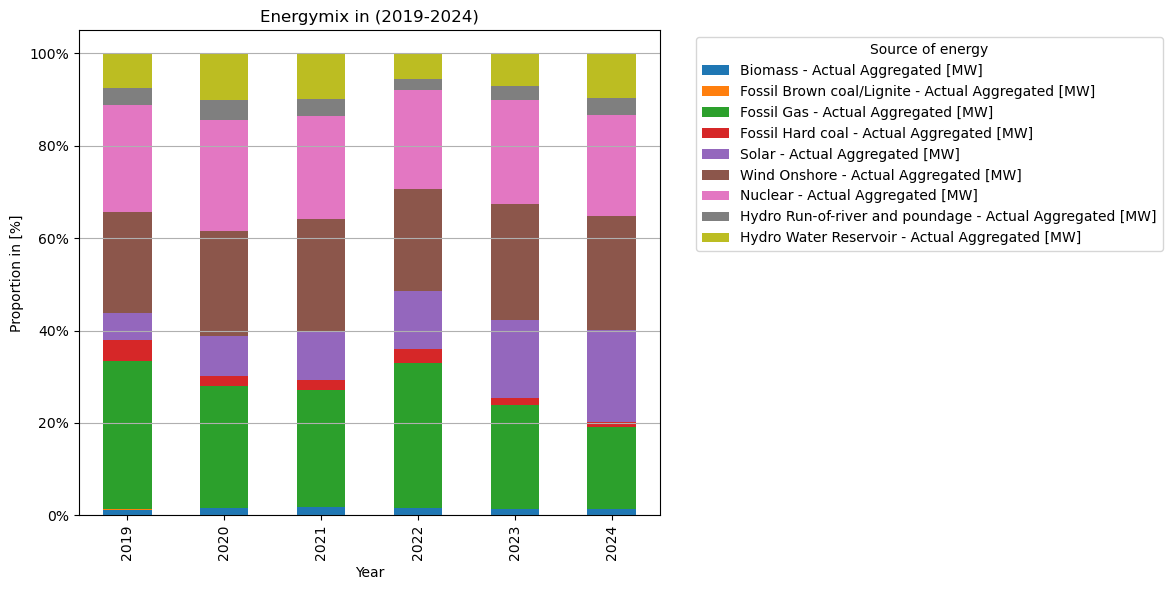

In [10]:
# ------------------------------------------------------------
# 10) VISUALIZE YEARLY ENERGY MIX (STACKED BAR)
# ------------------------------------------------------------
ax = yearly_generation_percentage.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Energymix in (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Proportion in [%]')
plt.legend(title='Source of energy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')

# Format the y-axis as percentages instead of decimal
ax.get_yaxis().set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()


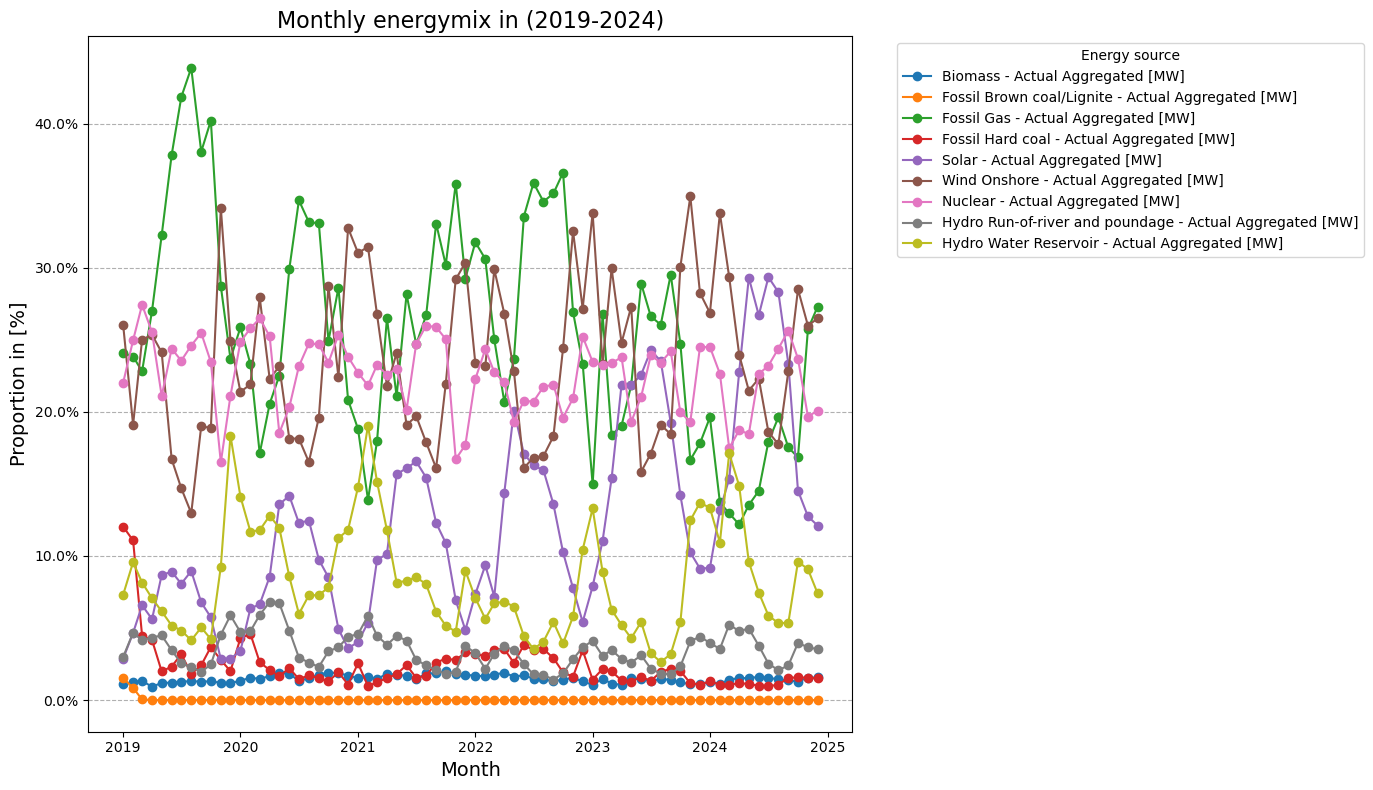

In [33]:
# ------------------------------------------------------------
# 11) MONTHLY SHARES LINE PLOT
# ------------------------------------------------------------
columns_to_exclude = ['Gas', 'Coal', 'Year', 'CO2_Intensity', 'Renewables']

# Group by Month, sum up, drop the columns we don't want to visualize,
# then compute the total for each month and convert to percentages.
monthly_shares = actual_generation.groupby('Month').sum().drop(columns=columns_to_exclude, errors='ignore')
monthly_totals = monthly_shares.sum(axis=1)
monthly_generation_percentage = monthly_shares.div(monthly_totals, axis=0) * 100

# Convert the index (which is YYYY-MM as a string) to a datetime (YYYY-MM-01)
monthly_generation_percentage.index = pd.to_datetime(monthly_generation_percentage.index + '-01')
monthly_generation_percentage = monthly_generation_percentage.sort_index()

# Plot a line for each remaining energy source
fig, ax = plt.subplots(figsize=(14, 8))
for column in monthly_generation_percentage.columns:
    ax.plot( monthly_generation_percentage.index, monthly_generation_percentage[column], marker='o', label=column)

plt.title('Monthly energymix in (2019-2024)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Proportion in [%]', fontsize=14)
plt.legend(title='Energy source', bbox_to_anchor=(1.05, 1), loc='upper left')

# Format y-axis as percentages
ax.get_yaxis().set_major_formatter(mtick.PercentFormatter())
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


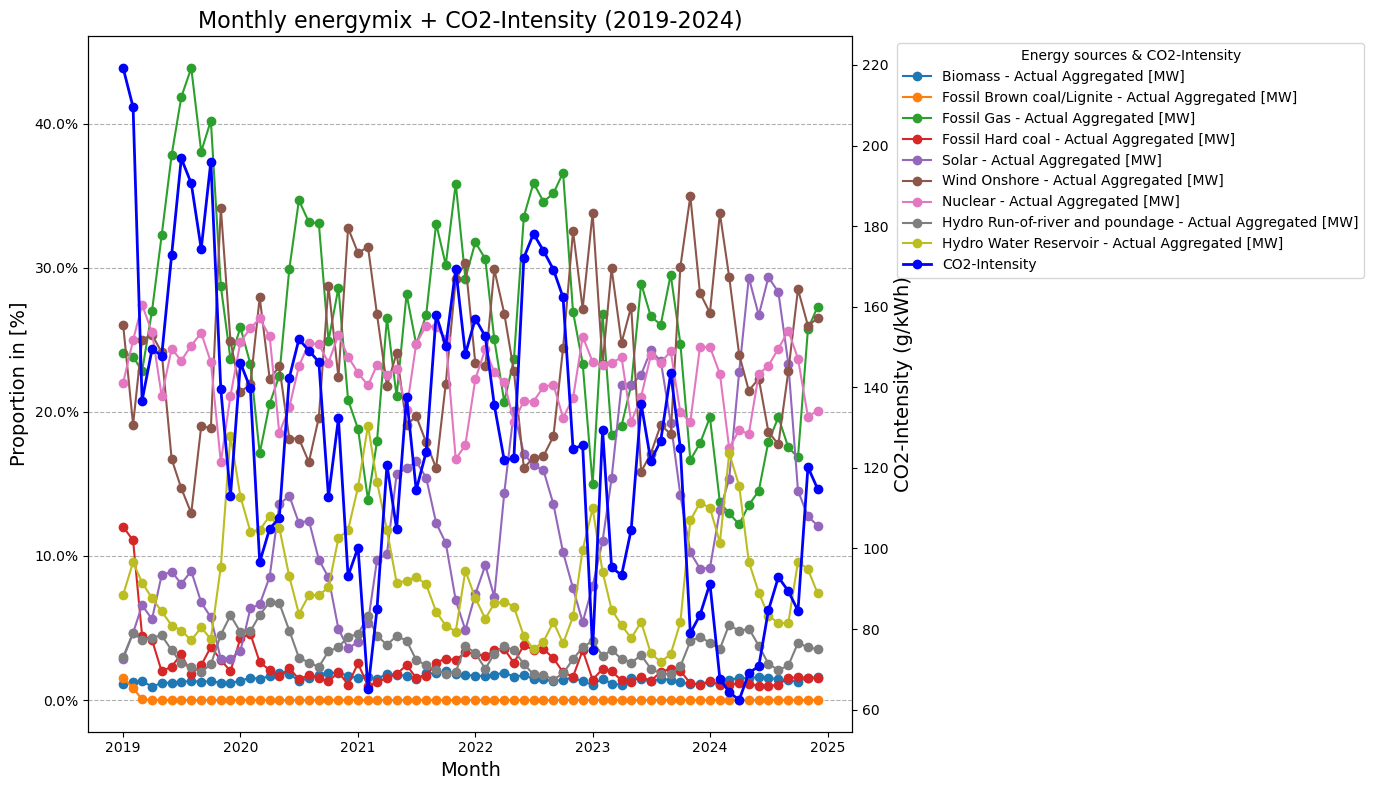

In [34]:
# ------------------------------------------------------------
# 12) MONTHLY SHARE + CO2 INTENSITY 
# ------------------------------------------------------------
columns_to_exclude = ['Gas', 'Coal', 'Year', 'Renewables', 'CO2_Intensity']

# Drop columns from monthly sums we don't need, convert to percentages
monthly_shares = actual_generation.groupby('Month').sum().drop(columns=columns_to_exclude, errors='ignore')
monthly_totals = monthly_shares.sum(axis=1)
monthly_generation_percentage = monthly_shares.div(monthly_totals, axis=0) * 100

# Convert index to datetime (to allow line plotting by date)
monthly_generation_percentage.index = pd.to_datetime(monthly_generation_percentage.index + '-01')
monthly_generation_percentage = monthly_generation_percentage.sort_index()

# Compute average CO2 intensity per month
monthly_co2_intensity = actual_generation.groupby('Month')['CO2_Intensity'].mean()
monthly_co2_intensity.index = pd.to_datetime(monthly_co2_intensity.index + '-01')
monthly_co2_intensity = monthly_co2_intensity.sort_index()

# Plot: the monthly energy shares on the primary axis, 
# CO2 intensity on the secondary axis
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot lines for each energy source
for column in monthly_generation_percentage.columns:
    ax1.plot(
        monthly_generation_percentage.index,
        monthly_generation_percentage[column],
        marker='o',
        label=column
    )

ax1.set_title('Monthly energymix + CO2-Intensity (2019-2024)', fontsize=16)
ax1.set_xlabel('Month', fontsize=14)
ax1.set_ylabel('Proportion in [%]', fontsize=14)
ax1.get_yaxis().set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis='y', linestyle='--')

# Create secondary y-axis for CO2 intensity
ax2 = ax1.twinx()
ax2.plot(monthly_co2_intensity.index,monthly_co2_intensity,color='blue',marker='o',linestyle='-',linewidth=2,label='CO2-Intensity')
ax2.set_ylabel('CO2-Intensity (g/kWh)', fontsize=14)
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title='Energy sources & CO2-Intensity',bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


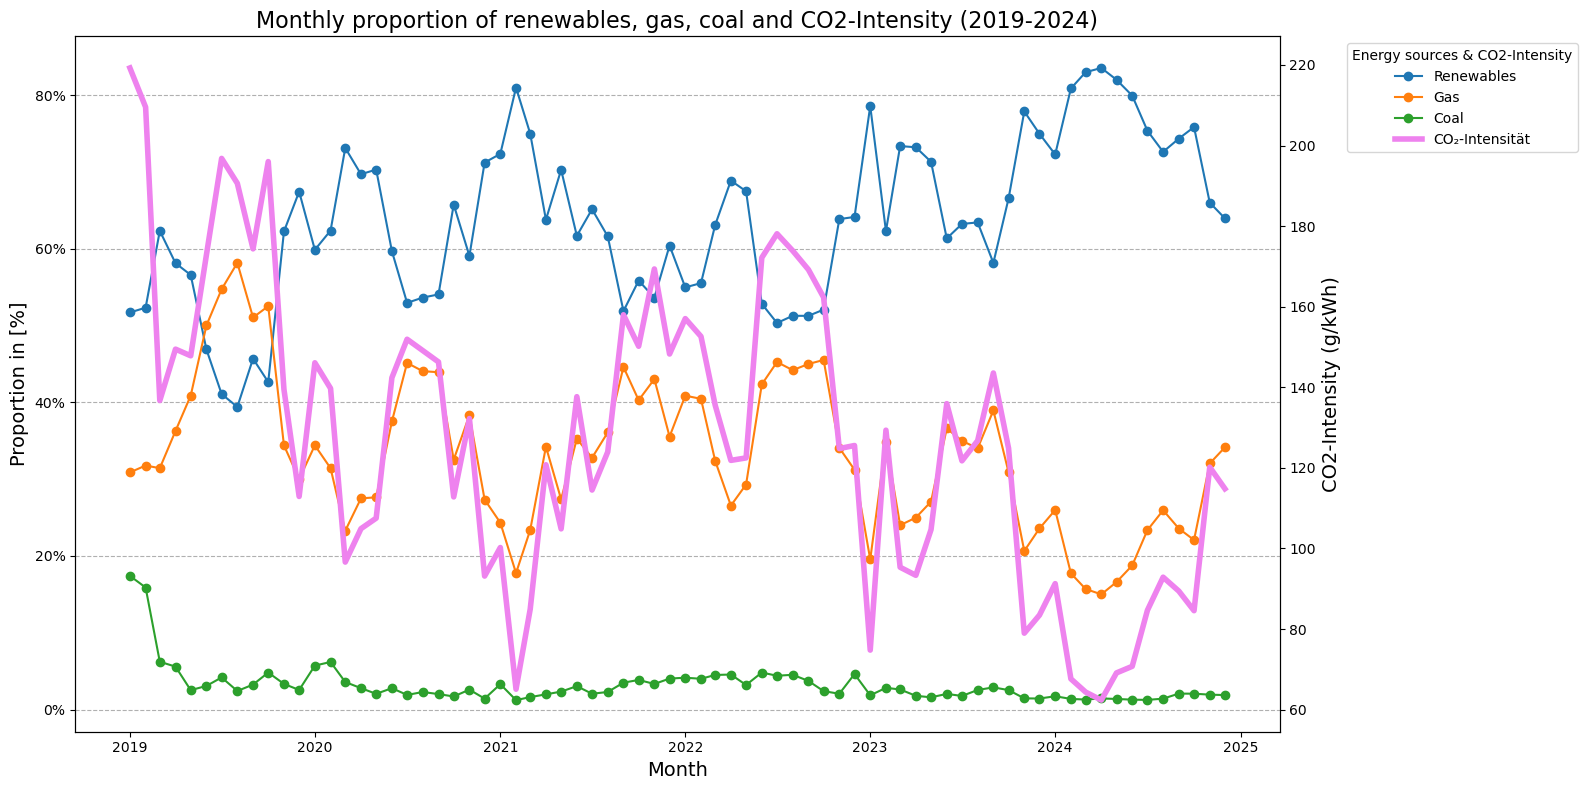

In [35]:
# ------------------------------------------------------------
# 13) MONTHLY SUMMARIES ONLY FOR RENEWABLES, GAS, COAL + CO2
# ------------------------------------------------------------
monthly_summaries = actual_generation.groupby('Month')[['Renewables', 'Gas', 'Coal']].sum()
monthly_summaries.index = pd.to_datetime(monthly_summaries.index + '-01')
monthly_summaries = monthly_summaries.sort_index()

# Compute the percentage of each (Renewables, Gas, Coal) in each month
monthly_totals = monthly_summaries.sum(axis=1)
monthly_summaries_percentage = monthly_summaries.div(monthly_totals, axis=0) * 100

# Calculate average monthly CO2 intensity again
monthly_co2_intensity = actual_generation.groupby('Month')['CO2_Intensity'].mean()
monthly_co2_intensity.index = pd.to_datetime(monthly_co2_intensity.index + '-01')
monthly_co2_intensity = monthly_co2_intensity.sort_index()

# Plot these monthly summaries on the primary axis and CO2 intensity on a secondary axis
fig, ax1 = plt.subplots(figsize=(16, 8))

# Plot lines for Renewables, Gas, Coal shares
for column in monthly_summaries_percentage.columns:
    ax1.plot(
        monthly_summaries_percentage.index,
        monthly_summaries_percentage[column],
        marker='o',
        label=column
    )

ax1.set_title('Monthly proportion of renewables, gas, coal and CO2-Intensity (2019-2024)', fontsize=16)
ax1.set_xlabel('Month', fontsize=14)
ax1.set_ylabel('Proportion in [%]', fontsize=14)
ax1.get_yaxis().set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis='y', linestyle='--')

ax2 = ax1.twinx()
ax2.plot(monthly_co2_intensity.index,  monthly_co2_intensity.values,color='violet',linestyle='-',linewidth=4,label='CO₂-Intensität')
ax2.set_ylabel('CO2-Intensity (g/kWh)', fontsize=14)
ax2.tick_params(axis='y', labelcolor='black')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title='Energy sources & CO2-Intensity', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [36]:
# ------------------------------------------------------------
# 14) PREPARE DATA FOR OLS REGRESSION
#     
# ------------------------------------------------------------

# yearly_shares: table with "Year" | "Renewables" | "Coal" | "Gas" 
yearly_shares = yearly_shares.reset_index()

# Add a numeric "Timestamp" column from "Year" to use as X in regression
yearly_shares['Timestamp'] = yearly_shares['Year'].astype(float)

# co2_data: group actual_generation by Year and  average CO2 intensity
co2_data = actual_generation.groupby('Year')['CO2_Intensity'].mean().reset_index()
co2_data['Timestamp'] = co2_data['Year'].astype(float)


# ------------------------------------------------------------
# 15) FUNCTIONS FOR OLS REGRESSION WITH STATSMODELS
# ------------------------------------------------------------
def perform_regression_ols(df, feature):
    """
    Sets up a simple OLS regression: feature ~ Timestamp.
    - df: DataFrame containing at least 'Timestamp' (the predictor) and the feature (the dependent variable).
    """
    # Independent variable: Timestamp
    # Add a constant to allow statsmodels to do an intercept.
    X = df[['Timestamp']].copy()
    X = sm.add_constant(X)
    
    # Dependent variable
    y = df[feature]
    
    # Create and fit the OLS model
    model = sm.OLS(y, X)
    results = model.fit()
    
    return results

def predict_year_ols(results, target_value):
    """
    Computes the year (x-value) where the OLS-predicted outcome reaches 'target_value'.
    For a simple model y = beta0 + beta1*x
    """
    intercept = results.params['const']       # beta0
    slope = results.params['Timestamp']       # beta1
    return (target_value - intercept) / slope


In [16]:
# ------------------------------------------------------------
# 16) FITTING OLS MODELS FOR RENEWABLES, GAS, COAL, AND CO2
# ------------------------------------------------------------
renewables_results = perform_regression_ols(yearly_shares, 'Renewables')
gas_results = perform_regression_ols(yearly_shares, 'Gas')
coal_results = perform_regression_ols(yearly_shares, 'Coal')
co2_results = perform_regression_ols(co2_data, 'CO2_Intensity')

In [37]:
# ------------------------------------------------------------
# 17) GIVEN THRESHOLDS AND PREDICT YEAR
# ------------------------------------------------------------
renewables_target = 85.0  # 85% renewable energy share
gas_target = 10.0         # reduce gas share to 10%
coal_target = 0.0         # 0% share
co2_target = 0.0          # 0 -CO2 intensity

year_renewables = predict_year_ols(renewables_results, renewables_target) # predict
year_gas = predict_year_ols(gas_results, gas_target)
year_coal = predict_year_ols(coal_results, coal_target)
year_co2 = predict_year_ols(co2_results, co2_target)

print("\nPredicted year with OLS:")
print(f"renewables > 85%: {year_renewables:.2f}")
print(f"gas < 10%: {year_gas:.2f}")
print(f"coal (0% Proportion): {year_coal:.2f}")
print(f"CO2-Neutral (0 g/kWh): {year_co2:.2f}")



Predicted year with OLS:
renewables > 85%: 2057.59
gas < 10%: 2024.77
coal (0% Proportion): 2026.36
CO2-Neutral (0 g/kWh): 2031.43


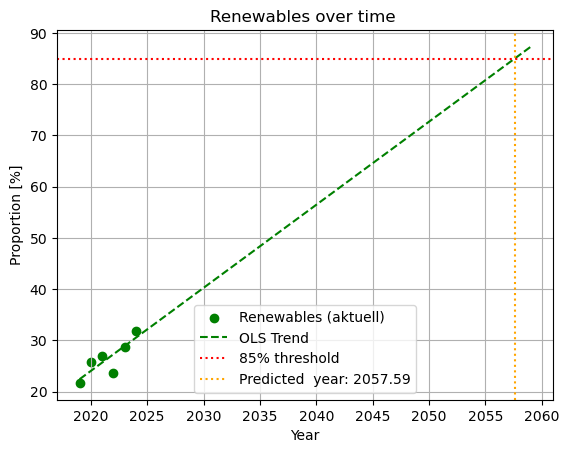

In [38]:
# ------------------------------------------------------------
# 18) PLOT THE OLS TRENDS FOR EACH MODEL
# ------------------------------------------------------------

# 18.1) Renewables share over extended timeline
extended_years = np.arange(yearly_shares['Year'].min(), 2060)
X_ext = sm.add_constant(pd.DataFrame({'Timestamp': extended_years.astype(float)}))
y_pred = renewables_results.predict(X_ext)

plt.scatter(yearly_shares['Year'], yearly_shares['Renewables'],label='Renewables (aktuell)',color='green')
plt.plot(extended_years,y_pred,label='OLS Trend',color='green',linestyle='--')

# Horizontal line for the 85% target
plt.axhline(85, color='red', linestyle=':', label='85% threshold')
# Vertical line for the predicted year
plt.axvline(year_renewables, color='orange', linestyle=':',label=f'Predicted  year: {year_renewables:.2f}')

plt.title('Renewables over time ')
plt.xlabel('Year')
plt.ylabel('Proportion [%]')
plt.legend()
plt.grid()
plt.show()


In [45]:
renewables_results.summary()

C:\Users\49176\anaconda3\envs\env-ede\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Renewables   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     9.122
Date:                Sun, 19 Jan 2025   Prob (F-statistic):             0.0392
Time:                        17:44:58   Log-Likelihood:                -12.152
No. Observations:                   6   AIC:                             28.30
Df Residuals:                       4   BIC:                             27.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3251.5866   1085.380     -2.996      0.040   -6265.086    -238.088
Timestamp      1.6216      0.537      3.020      0.039       0.131       3.112
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.228
Prob(Omnibus):                    nan   Jarque-Bera (JB):                1.020
Skew:                          -1.000   Prob(JB):                        0.600
Kurtosis:                       2.720   Cond. No.                     2.39e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.39e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

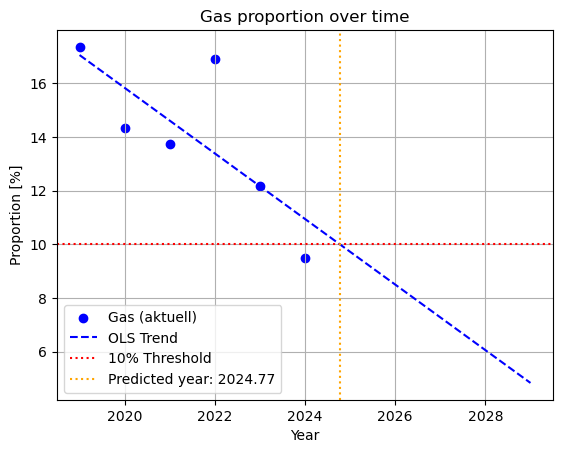

In [41]:
# 18.2) Gas share over extended timeline
extended_years = np.arange(yearly_shares['Year'].min(), 2030)
X_ext = sm.add_constant(pd.DataFrame({'Timestamp': extended_years.astype(float)}))
y_pred = gas_results.predict(X_ext)

plt.scatter(yearly_shares['Year'], yearly_shares['Gas'], label='Gas (aktuell)', color='blue')
plt.plot(extended_years,y_pred,label='OLS Trend',color='blue',linestyle='--')

# Horizontal line for the 10% target
plt.axhline(10, color='red', linestyle=':', label='10% Threshold')
# Vertical line for the predicted year
plt.axvline(year_gas, color='orange', linestyle=':', label=f'Predicted year: {year_gas:.2f}')

plt.title('Gas proportion over time')
plt.xlabel('Year')
plt.ylabel('Proportion [%]')
plt.legend()
plt.grid()
plt.show()

In [46]:
gas_results.summary()

C:\Users\49176\anaconda3\envs\env-ede\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    Gas   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     5.890
Date:                Sun, 19 Jan 2025   Prob (F-statistic):             0.0722
Time:                        17:45:13   Log-Likelihood:                -11.761
No. Observations:                   6   AIC:                             27.52
Df Residuals:                       4   BIC:                             27.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2481.8293   1016.831      2.441      0.071    -341.347    5305.005
Timestamp     -1.2208      0.503     -2.427      0.072      -2.617       0.176
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.127
Prob(Omnibus):                    nan   Jarque-Bera (JB):                1.484
Skew:                           1.215   Prob(JB):                        0.476
Kurtosis:                       3.173   Cond. No.                     2.39e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.39e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

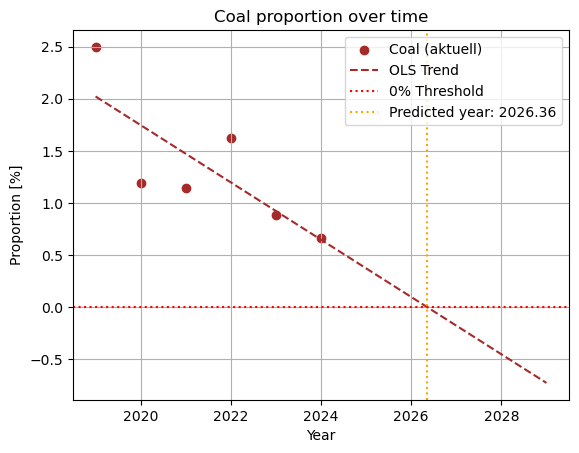

In [42]:
# 18.3) Coal share over extended timeline
extended_years = np.arange(yearly_shares['Year'].min(), 2030)
X_ext = sm.add_constant(pd.DataFrame({'Timestamp': extended_years.astype(float)}))
y_pred = coal_results.predict(X_ext)

plt.scatter(yearly_shares['Year'],yearly_shares['Coal'],label='Coal (aktuell)',color='brown')
plt.plot(extended_years,y_pred,label='OLS Trend',color='brown',linestyle='--')

# Horizontal line for the 0% target
plt.axhline(0, color='red', linestyle=':', label='0% Threshold')
# Vertical line for the predicted year
plt.axvline(year_coal, color='orange', linestyle=':', label=f'Predicted year: {year_coal:.2f}')

plt.title('Coal proportion over time')
plt.xlabel('Year')
plt.ylabel('Proportion [%]')
plt.legend()
plt.grid()
plt.show()


In [47]:
coal_results.summary()

C:\Users\49176\anaconda3\envs\env-ede\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Coal   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     6.457
Date:                Sun, 19 Jan 2025   Prob (F-statistic):             0.0639
Time:                        17:45:25   Log-Likelihood:                -2.5391
No. Observations:                   6   AIC:                             9.078
Df Residuals:                       4   BIC:                             8.662
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        556.9469    218.651      2.547      0.063     -50.126    1164.020
Timestamp     -0.2749      0.108     -2.541      0.064      -0.575       0.025
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.307
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.443
Skew:                          -0.061   Prob(JB):                        0.801
Kurtosis:                       1.675   Cond. No.                     2.39e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.39e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

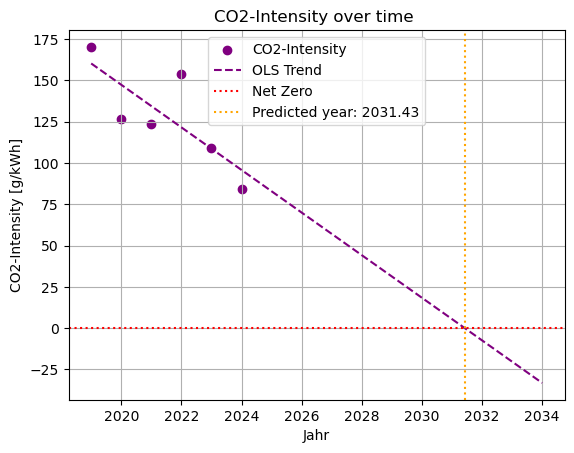

In [44]:
# 18.4) CO2 intensity over an extended timeline
co2_data = actual_generation.groupby('Year')['CO2_Intensity'].mean().reset_index()
co2_data['Timestamp'] = co2_data['Year'].astype(float)

extended_years = np.arange(co2_data['Year'].min(), 2035)
X_ext = sm.add_constant(pd.DataFrame({'Timestamp': extended_years.astype(float)}))
y_pred = co2_results.predict(X_ext)

plt.scatter(co2_data['Year'], co2_data['CO2_Intensity'], label='CO2-Intensity', color='purple')
plt.plot( extended_years, y_pred, label='OLS Trend', color='purple', linestyle='--')

# Horizontal line for net-zero
plt.axhline(0, color='red', linestyle=':', label='Net Zero')
# Vertical line for the predicted net-zero year
plt.axvline(year_co2, color='orange', linestyle=':', label=f'Predicted year: {year_co2:.2f}')

plt.title('CO2-Intensity over time ')
plt.xlabel('Jahr')
plt.ylabel('CO2-Intensity [g/kWh]')
plt.legend()
plt.grid()
plt.show()

In [48]:
co2_results.summary()

C:\Users\49176\anaconda3\envs\env-ede\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2_Intensity   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     6.332
Date:                Sun, 19 Jan 2025   Prob (F-statistic):             0.0656
Time:                        17:45:35   Log-Likelihood:                -25.688
No. Observations:                   6   AIC:                             55.38
Df Residuals:                       4   BIC:                             54.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.62e+04   1.04e+04      2.529      0.065   -2567.078     5.5e+04
Timestamp    -12.8953      5.125     -2.516      0.066     -27.124       1.333
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.232
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.647
Skew:                           0.744   Prob(JB):                        0.724
Kurtosis:                       2.391   Cond. No.                     2.39e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.39e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""